In [1]:
%cd ..

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics


In [2]:
import os

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics'

In [3]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [4]:
from aspect_turquoise import Turquoise

In [5]:
from generator_core.impl.Vocabulary import SimpleVocabulary
import numpy as np
import torch

In [6]:
from generator_core import Trainer

In [7]:
solution = Turquoise()

In [8]:
streamer = solution.load_dataset()

In [9]:
next(streamer.stream())

["Ahe's My Kind Of Girl",
 'ABBA',
 "Look at her face, it's a wonderful face  \nAnd it means something special to me  \nLook at the way that she smiles when she sees me  \nHow lucky can one fellow be?  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?  \n  \nAnd when we go for a walk in the park  \nAnd she holds me and squeezes my hand  \nWe'll go on walking for hours and talking  \nAbout all the things that we plan  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?\n\n",
 'null']

In [10]:
small_dataset = []
for line in streamer.stream():
    small_dataset.append(line)
    if len(small_dataset) > 100:
        break

In [11]:
_, _, content, _ = small_dataset[0]
content

"Look at her face, it's a wonderful face  \nAnd it means something special to me  \nLook at the way that she smiles when she sees me  \nHow lucky can one fellow be?  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?  \n  \nAnd when we go for a walk in the park  \nAnd she holds me and squeezes my hand  \nWe'll go on walking for hours and talking  \nAbout all the things that we plan  \n  \nShe's just my kind of girl, she makes me feel fine  \nWho could ever believe that she could be mine?  \nShe's just my kind of girl, without her I'm blue  \nAnd if she ever leaves me what could I do, what could I do?\n\n"

In [12]:
content = solution.clean_text(content)
content

"look at her face , it's a wonderful face \n and it means something special to me \n look at the way that she smiles when she sees me \n how lucky can one fellow be ? \n \n she's just my kind of girl , she makes me feel fine \n who could ever believe that she could be mine ? \n she's just my kind of girl , without her i'm blue \n and if she ever leaves me what could i do , what could i do ? \n \n and when we go for a walk in the park \n and she holds me and squeezes my hand \n we'll go on walking for hours and talking \n about all the things that we plan \n \n she's just my kind of girl , she makes me feel fine \n who could ever believe that she could be mine ? \n she's just my kind of girl , without her i'm blue \n and if she ever leaves me what could i do , what could i do ?"

In [13]:
annotation = solution.annotate_text(content)
annotation

In [14]:
literal_tokens = solution.tokenize_text(content)
print(literal_tokens)

['<SONG_START>', 'look', 'at', 'her', 'face', ',', "it's", 'a', 'wonderful', 'face', '<LINE>', 'and', 'it', 'means', 'something', 'special', 'to', 'me', '<LINE>', 'look', 'at', 'the', 'way', 'that', 'she', 'smiles', 'when', 'she', 'sees', 'me', '<LINE>', 'how', 'lucky', 'can', 'one', 'fellow', 'be', '?', '<LINE>', '<LINE>', "she's", 'just', 'my', 'kind', 'of', 'girl', ',', 'she', 'makes', 'me', 'feel', 'fine', '<LINE>', 'who', 'could', 'ever', 'believe', 'that', 'she', 'could', 'be', 'mine', '?', '<LINE>', "she's", 'just', 'my', 'kind', 'of', 'girl', ',', 'without', 'her', "i'm", 'blue', '<LINE>', 'and', 'if', 'she', 'ever', 'leaves', 'me', 'what', 'could', 'i', 'do', ',', 'what', 'could', 'i', 'do', '?', '<LINE>', '<LINE>', 'and', 'when', 'we', 'go', 'for', 'a', 'walk', 'in', 'the', 'park', '<LINE>', 'and', 'she', 'holds', 'me', 'and', 'squeezes', 'my', 'hand', '<LINE>', "we'll", 'go', 'on', 'walking', 'for', 'hours', 'and', 'talking', '<LINE>', 'about', 'all', 'the', 'things', 'that'

In [15]:
solution.vocabulary = SimpleVocabulary({"<SONG_START>", "<SONG_END>", "<LINE>", "<STANZA>"})
for token in literal_tokens:
    vocabulary = solution.build_vocabulary(token)
len(vocabulary)

26

In [16]:
print(solution.vocabulary.word2idx)

{'<PAD>': 0, '<UNKNOWN>': 1, '<SONG_START>': 2, '<STANZA>': 3, '<LINE>': 4, '<SONG_END>': 5, 'she': 6, 'me': 7, ',': 8, 'could': 9, '?': 10, 'and': 11, 'my': 12, 'the': 13, 'that': 14, "she's": 15, 'just': 16, 'kind': 17, 'of': 18, 'girl': 19, 'ever': 20, 'be': 21, 'her': 22, 'what': 23, 'i': 24, 'do': 25}


In [17]:
indicial_tokens = np.zeros(len(literal_tokens), dtype=np.long)
for i, token in enumerate(literal_tokens): indicial_tokens[i] = vocabulary.encode(token)
indicial_tokens

array([ 2,  1,  1, 22,  1,  8,  1,  1,  1,  1,  4, 11,  1,  1,  1,  1,  1,
        7,  4,  1,  1, 13,  1, 14,  6,  1,  1,  6,  1,  7,  4,  1,  1,  1,
        1,  1, 21, 10,  4,  4, 15, 16, 12, 17, 18, 19,  8,  6,  1,  7,  1,
        1,  4,  1,  9, 20,  1, 14,  6,  9, 21,  1, 10,  4, 15, 16, 12, 17,
       18, 19,  8,  1, 22,  1,  1,  4, 11,  1,  6, 20,  1,  7, 23,  9, 24,
       25,  8, 23,  9, 24, 25, 10,  4,  4, 11,  1,  1,  1,  1,  1,  1,  1,
       13,  1,  4, 11,  6,  1,  7, 11,  1, 12,  1,  4,  1,  1,  1,  1,  1,
        1, 11,  1,  4,  1,  1, 13,  1, 14,  1,  1,  4,  4, 15, 16, 12, 17,
       18, 19,  8,  6,  1,  7,  1,  1,  4,  1,  9, 20,  1, 14,  6,  9, 21,
        1, 10,  4, 15, 16, 12, 17, 18, 19,  8,  1, 22,  1,  1,  4, 11,  1,
        6, 20,  1,  7, 23,  9, 24, 25,  8, 23,  9, 24, 25, 10,  5],
      dtype=int32)

In [18]:
indicial_tokens.max()

np.int32(25)

In [19]:
solution.prepare_embedder(None)

In [20]:
embeds = solution.embed_tokens(indicial_tokens)
embeds

array([ 2,  1,  1, 22,  1,  8,  1,  1,  1,  1,  4, 11,  1,  1,  1,  1,  1,
        7,  4,  1,  1, 13,  1, 14,  6,  1,  1,  6,  1,  7,  4,  1,  1,  1,
        1,  1, 21, 10,  4,  4, 15, 16, 12, 17, 18, 19,  8,  6,  1,  7,  1,
        1,  4,  1,  9, 20,  1, 14,  6,  9, 21,  1, 10,  4, 15, 16, 12, 17,
       18, 19,  8,  1, 22,  1,  1,  4, 11,  1,  6, 20,  1,  7, 23,  9, 24,
       25,  8, 23,  9, 24, 25, 10,  4,  4, 11,  1,  1,  1,  1,  1,  1,  1,
       13,  1,  4, 11,  6,  1,  7, 11,  1, 12,  1,  4,  1,  1,  1,  1,  1,
        1, 11,  1,  4,  1,  1, 13,  1, 14,  1,  1,  4,  4, 15, 16, 12, 17,
       18, 19,  8,  6,  1,  7,  1,  1,  4,  1,  9, 20,  1, 14,  6,  9, 21,
        1, 10,  4, 15, 16, 12, 17, 18, 19,  8,  1, 22,  1,  1,  4, 11,  1,
        6, 20,  1,  7, 23,  9, 24, 25,  8, 23,  9, 24, 25, 10,  5],
      dtype=int32)

In [21]:
sample = solution.inject_sample(embeds, annotation)
sample

array([ 2,  1,  1, 22,  1,  8,  1,  1,  1,  1,  4, 11,  1,  1,  1,  1,  1,
        7,  4,  1,  1, 13,  1, 14,  6,  1,  1,  6,  1,  7,  4,  1,  1,  1,
        1,  1, 21, 10,  4,  4, 15, 16, 12, 17, 18, 19,  8,  6,  1,  7,  1,
        1,  4,  1,  9, 20,  1, 14,  6,  9, 21,  1, 10,  4, 15, 16, 12, 17,
       18, 19,  8,  1, 22,  1,  1,  4, 11,  1,  6, 20,  1,  7, 23,  9, 24,
       25,  8, 23,  9, 24, 25, 10,  4,  4, 11,  1,  1,  1,  1,  1,  1,  1,
       13,  1,  4, 11,  6,  1,  7, 11,  1, 12,  1,  4,  1,  1,  1,  1,  1,
        1, 11,  1,  4,  1,  1, 13,  1, 14,  1,  1,  4,  4, 15, 16, 12, 17,
       18, 19,  8,  6,  1,  7,  1,  1,  4,  1,  9, 20,  1, 14,  6,  9, 21,
        1, 10,  4, 15, 16, 12, 17, 18, 19,  8,  1, 22,  1,  1,  4, 11,  1,
        6, 20,  1,  7, 23,  9, 24, 25,  8, 23,  9, 24, 25, 10,  5],
      dtype=int32)

In [22]:
model = solution.prepare_model()
model

SimpleEncoderDecoderModel(
  (encoder): _Encoder(
    (embedding): Embedding(26, 256, padding_idx=0)
    (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
    (linear_hidden): Linear(in_features=512, out_features=256, bias=True)
    (linear_cell): Linear(in_features=512, out_features=256, bias=True)
  )
  (decoder): _Decoder(
    (embedding): Embedding(26, 256, padding_idx=0)
    (lstm): LSTM(256, 256, batch_first=True)
    (linear_out): Linear(in_features=256, out_features=26, bias=True)
  )
)

In [72]:
print("Hmm")
preds = model.forward(torch.tensor(sample[None, :20].astype(np.long)))
print("Hmm")

Hmm
Hmm


In [73]:
preds.shape

torch.Size([1, 10, 26])

In [74]:
indices = preds.detach().argmax(2)[0]
for x in indices: print(x, vocabulary.decode(x.item()))

tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>
tensor(5) <SONG_END>


In [75]:
preds=preds.detach().numpy()

In [76]:
import matplotlib.pyplot as plt

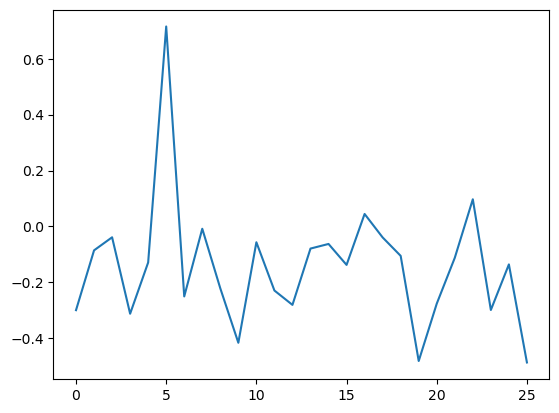

In [77]:
plt.plot(preds[0, 8, :])
plt.show()

In [79]:
indices = preds[0, :, 6:].argmax(1)
for x in indices: print(x, vocabulary.decode(x.item()))

16 just
12 my
12 my
16 just
16 just
16 just
16 just
16 just
16 just
16 just


In [26]:
from torch.utils.data import IterableDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


In [60]:
def collate_fn(batch, pad_idx=0):
    xs, ys = list(zip(*batch))
    xs = pad_sequence(xs, batch_first=True, padding_value=pad_idx)
    # ys = pad_sequence(ys, batch_first=True, padding_value=pad_idx)
    ys = torch.stack(ys)
    # print("xs, ys", xs.shape, ys.shape)  # torch.Size([2, 633]) torch.Size([2, 633])
    return xs, ys

In [61]:
for _, _, content, _ in small_dataset:
    solution.vocabulary = SimpleVocabulary({"<SONG_START>", "<SONG_END>", "<LINE>", "<STANZA>"})
    for token in literal_tokens:
        vocabulary = solution.build_vocabulary(token)

model = solution.prepare_model()


class MyDataset(IterableDataset):
    def __iter__(self):
        for _, _, content, _ in small_dataset:
            content = solution.clean_text(content)
            annotation = solution.annotate_text(content)
            literal_tokens = solution.tokenize_text(content)
            indicial_tokens = np.zeros(len(literal_tokens), dtype=np.long)
            for i, token in enumerate(literal_tokens): indicial_tokens[i] = vocabulary.encode(token)
            solution.prepare_embedder(None)
            embeds = solution.embed_tokens(indicial_tokens)
            sample = solution.inject_sample(embeds, annotation)
            sample = torch.tensor(sample.astype(np.long))
            # print("sample[:-1], sample[1:]", sample[:-1].shape, sample[1:].shape)  # sample[1:] torch.Size([178]) torch.Size([178])
            yield sample[:-1], sample[-1].type(torch.long)


loader = DataLoader(
    MyDataset(),
    batch_size=2,
    collate_fn=collate_fn,
)

In [64]:
trainer = Trainer(
    model=model,
    train_dataloader=loader,
    epochs=1,
    # model_train_step=lambda model, x, y: model(x, y).permute(0, 2, 1), # [batch, seq, vocab] to [batch, vocab, seq]
    model_train_step=lambda model, x, y: model(x, max_evals=1)[:, 0, :],
)

In [65]:
print("Poof")
trainer.train()
print("Poof")

Poof


IndexError: list index out of range

In [66]:
trainer.loss

{'train': [np.float64(0.1547597980551312)], 'val': []}